подготовительные дейтсвия

In [12]:
import sys, os
import graphviz
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}
from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

In [13]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


In [14]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


визуализация графа

In [15]:
from mdp import has_graphviz
from IPython.display import display

print("Graphviz available:", has_graphviz)
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

Graphviz available: False


итерации по значениям

In [8]:
def get_action_value(mdp, state_values, state, action, gamma):
    q = 0
    next_states = mdp.get_next_states(state, action)
    for next_state, prob in next_states.items():
        reward = mdp.get_reward(state, action, next_state)
        q += prob * (reward + gamma * state_values[next_state])
    return q

In [9]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

In [10]:
def get_new_state_value(mdp, state_values, state, gamma):
    if mdp.is_terminal(state):
        return 0
    possible_actions = mdp.get_possible_actions(state)
    best_value = max(get_action_value(mdp, state_values, state, action, gamma)
                     for action in possible_actions)
    return best_value

In [11]:
# параметры
gamma = 0.9 # дисконт MDP
num_iter = 100 # максимальное число итераций, за исключением инициализации
# Останавливаем VI если новые значения ближе к старым менее чем:
min_difference = 0.001
# инициализация V(s)
state_values = {s: 0 for s in mdp.get_all_states()}
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))
for i in range(num_iter):
    # Вычисление новых значений состояния, используя ранее написанные функции.
    # Они имеют формат словаря {state : float V_new(state)}
    new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma)
                        for s in mdp.get_all_states()}
    assert isinstance(new_state_values, dict)
    # Вычисление отклонений
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i | diff: %6.5f | " % (i, diff), end="")
    print(' '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values
    if diff < min_difference:
        print("Terminated")
        break

iter    0 | diff: 3.50000 | V(s0) = 0.000 V(s1) = 0.000 V(s2) = 0.000
iter    1 | diff: 0.64500 | V(s0) = 0.000 V(s1) = 3.500 V(s2) = 0.000
iter    2 | diff: 0.58050 | V(s0) = 0.000 V(s1) = 3.815 V(s2) = 0.645
iter    3 | diff: 0.43582 | V(s0) = 0.581 V(s1) = 3.959 V(s2) = 0.962
iter    4 | diff: 0.30634 | V(s0) = 0.866 V(s1) = 4.395 V(s2) = 1.272
iter    5 | diff: 0.27571 | V(s0) = 1.145 V(s1) = 4.670 V(s2) = 1.579
iter    6 | diff: 0.24347 | V(s0) = 1.421 V(s1) = 4.926 V(s2) = 1.838
iter    7 | diff: 0.21419 | V(s0) = 1.655 V(s1) = 5.169 V(s2) = 2.075
iter    8 | diff: 0.19277 | V(s0) = 1.868 V(s1) = 5.381 V(s2) = 2.290
iter    9 | diff: 0.17327 | V(s0) = 2.061 V(s1) = 5.573 V(s2) = 2.481
iter   10 | diff: 0.15569 | V(s0) = 2.233 V(s1) = 5.746 V(s2) = 2.654
iter   11 | diff: 0.14012 | V(s0) = 2.389 V(s1) = 5.902 V(s2) = 2.810
iter   12 | diff: 0.12610 | V(s0) = 2.529 V(s1) = 6.042 V(s2) = 2.950
iter   13 | diff: 0.11348 | V(s0) = 2.655 V(s1) = 6.168 V(s2) = 3.076
iter   14 | diff: 0.

In [16]:
assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

In [18]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    if mdp.is_terminal(state):
        return None
    actions = mdp.get_possible_actions(state)
    optimal_action = max(actions, key=lambda a: get_action_value(mdp, state_values, state, a, gamma))
    return optimal_action

In [19]:

assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'
assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
"Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
"Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."

In [20]:
# Измерение среднего вознаграждения агента
s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)
print("average reward: ", np.mean(rewards))
assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4736


Среда Frozen lake

In [21]:
#Frozen Lake Env
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)
mdp.render()

*FFF
FHFH
FFFH
HFFG



In [22]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):
        # Вычислите новые значения состояния, используя функции, которые вы определили выше. Это
        # должен быть dict {state: new_V(state)}
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}
        assert isinstance(new_state_values, dict)
        # Вычисление отклонений
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())
        print("iter %4i | diff: %.6f | V(start): %.3f" %
              (i, diff, new_state_values[mdp._initial_state]))
        state_values = new_state_values
        if diff < min_difference:
            break
    return state_values

In [23]:
state_values = value_iteration(mdp)
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

iter    0 | diff: 1.000000 | V(start): 0.000
iter    1 | diff: 0.900000 | V(start): 0.000
iter    2 | diff: 0.810000 | V(start): 0.000
iter    3 | diff: 0.729000 | V(start): 0.000
iter    4 | diff: 0.656100 | V(start): 0.000
iter    5 | diff: 0.590490 | V(start): 0.590
iter    6 | diff: 0.000000 | V(start): 0.590
*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



In [24]:
import matplotlib.pyplot as plt

def draw_policy(mdp, state_values, gamma=0.9):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}

    plt.imshow(V.reshape(h, w), cmap='gray', interpolation='none', clim=(0, 1))

    ax = plt.gca()
    ax.set_xticks(np.arange(w + 1) - 0.5)
    ax.set_yticks(np.arange(h + 1) - 0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, color='b', lw=2, ls='-')
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}

    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12, va='center', ha='center', fontweight='bold')
            action = Pi.get((y, x))
            if action is None:
                continue
            u, v = a2uv[action]
            plt.arrow(x, y, u * 0.4, -v * 0.4,
                      color='red', head_width=0.2, head_length=0.2, linewidth=2)
    plt.show()

after iteration 0
iter    0 | diff: 1.000000 | V(start): 0.000


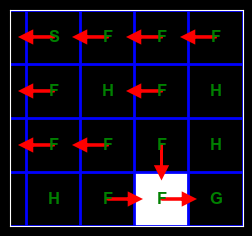

after iteration 1
iter    0 | diff: 0.900000 | V(start): 0.000


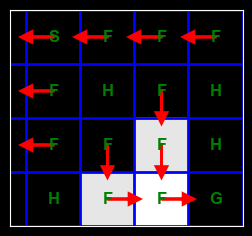

after iteration 2
iter    0 | diff: 0.810000 | V(start): 0.000


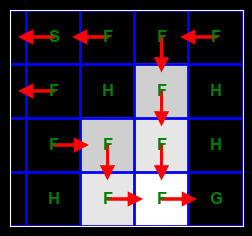

after iteration 3
iter    0 | diff: 0.729000 | V(start): 0.000


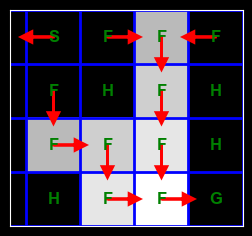

after iteration 4
iter    0 | diff: 0.656100 | V(start): 0.000


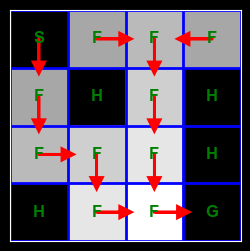

after iteration 5
iter    0 | diff: 0.590490 | V(start): 0.590


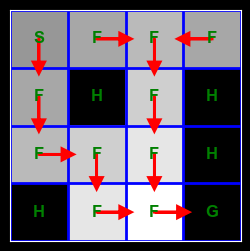

after iteration 6
iter    0 | diff: 0.000000 | V(start): 0.590


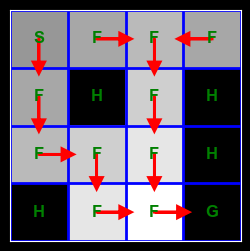

after iteration 7
iter    0 | diff: 0.000000 | V(start): 0.590


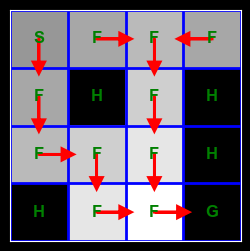

after iteration 8
iter    0 | diff: 0.000000 | V(start): 0.590


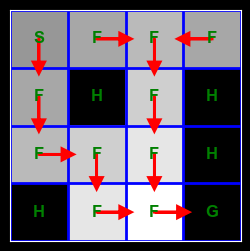

after iteration 9
iter    0 | diff: 0.000000 | V(start): 0.590


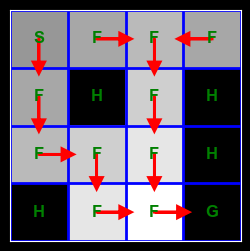

In [25]:
state_values = {s: 0 for s in mdp.get_all_states()}
for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0 | diff: 0.000000 | V(start): 0.198


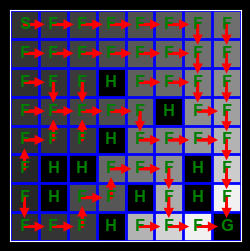

In [26]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}
for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

In [27]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)
total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))
print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0 | diff: 1.000000 | V(start): 0.000
iter    1 | diff: 0.900000 | V(start): 0.000
iter    2 | diff: 0.810000 | V(start): 0.000
iter    3 | diff: 0.729000 | V(start): 0.000
iter    4 | diff: 0.656100 | V(start): 0.000
iter    5 | diff: 0.590490 | V(start): 0.590
iter    6 | diff: 0.000000 | V(start): 0.590
average reward:  1.0
Well done!


In [28]:
# Значение среднего вознаграждения агента
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)
total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))
print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0 | diff: 0.900000 | V(start): 0.000
iter    1 | diff: 0.729000 | V(start): 0.000
iter    2 | diff: 0.623295 | V(start): 0.000
iter    3 | diff: 0.504869 | V(start): 0.000
iter    4 | diff: 0.408944 | V(start): 0.000
iter    5 | diff: 0.348678 | V(start): 0.349
iter    6 | diff: 0.065290 | V(start): 0.410
iter    7 | diff: 0.058322 | V(start): 0.468
iter    8 | diff: 0.011394 | V(start): 0.480
iter    9 | diff: 0.007637 | V(start): 0.487
iter   10 | diff: 0.001641 | V(start): 0.489
iter   11 | diff: 0.000937 | V(start): 0.490
iter   12 | diff: 0.000218 | V(start): 0.490
iter   13 | diff: 0.000113 | V(start): 0.490
iter   14 | diff: 0.000028 | V(start): 0.490
iter   15 | diff: 0.000014 | V(start): 0.490
iter   16 | diff: 0.000004 | V(start): 0.490
average reward:  0.872
Well done!


In [29]:

# Значение среднего вознаграждения агента
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)
total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))
print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0 | diff: 0.750000 | V(start): 0.000
iter    1 | diff: 0.506250 | V(start): 0.000
iter    2 | diff: 0.398672 | V(start): 0.000
iter    3 | diff: 0.269104 | V(start): 0.000
iter    4 | diff: 0.181645 | V(start): 0.000
iter    5 | diff: 0.140126 | V(start): 0.140
iter    6 | diff: 0.070282 | V(start): 0.199
iter    7 | diff: 0.060298 | V(start): 0.260
iter    8 | diff: 0.025937 | V(start): 0.285
iter    9 | diff: 0.019180 | V(start): 0.305
iter   10 | diff: 0.008580 | V(start): 0.313
iter   11 | diff: 0.005596 | V(start): 0.319
iter   12 | diff: 0.002598 | V(start): 0.321
iter   13 | diff: 0.001586 | V(start): 0.323
iter   14 | diff: 0.000760 | V(start): 0.324
iter   15 | diff: 0.000445 | V(start): 0.324
iter   16 | diff: 0.000219 | V(start): 0.324
iter   17 | diff: 0.000125 | V(start): 0.325
iter   18 | diff: 0.000062 | V(start): 0.325
iter   19 | diff: 0.000035 | V(start): 0.325
iter   20 | diff: 0.000018 | V(start): 0.325
iter   21 | diff: 0.000010 | V(start): 0.325
average re

In [30]:
# Значение среднего вознаграждения агента
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)
total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))
print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0 | diff: 0.800000 | V(start): 0.000
iter    1 | diff: 0.576000 | V(start): 0.000
iter    2 | diff: 0.414720 | V(start): 0.000
iter    3 | diff: 0.298598 | V(start): 0.000
iter    4 | diff: 0.241865 | V(start): 0.000
iter    5 | diff: 0.193492 | V(start): 0.000
iter    6 | diff: 0.153245 | V(start): 0.000
iter    7 | diff: 0.122875 | V(start): 0.000
iter    8 | diff: 0.099303 | V(start): 0.000
iter    9 | diff: 0.080375 | V(start): 0.000
iter   10 | diff: 0.064261 | V(start): 0.000
iter   11 | diff: 0.051290 | V(start): 0.000
iter   12 | diff: 0.043304 | V(start): 0.000
iter   13 | diff: 0.038023 | V(start): 0.033
iter   14 | diff: 0.033316 | V(start): 0.058
iter   15 | diff: 0.029095 | V(start): 0.087
iter   16 | diff: 0.018554 | V(start): 0.106
iter   17 | diff: 0.014032 | V(start): 0.120
iter   18 | diff: 0.008097 | V(start): 0.128
iter   19 | diff: 0.005551 | V(start): 0.133
iter   20 | diff: 0.003208 | V(start): 0.137
iter   21 | diff: 0.002465 | V(start): 0.138
iter   22 